# PRODUTO DADOS PADAP

## Engenharia de dados

### Importação de bibliotecas

In [1]:
import pandas as pd
import requests
from io import StringIO
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_p = "https://tess.pareto.io/api/agents"
headers = {
    "Authorization": "1389|fx2SXyeH2T2Hby1DJ09Vyiez4XA9cpkqKwrNGfCvfda2b5f5"
}

response = requests.get(url_p, headers=headers)
print(response.json())

{'message': 'Unauthenticated.'}


### Carregamento de dados CONAB

In [ ]:


# URL do arquivo
url = "https://portaldeinformacoes.conab.gov.br/downloads/arquivos/PrecosSemanalMunicipio.txt"

# Fazer o download do arquivo
response = requests.get(url)


# Verificar se o download foi bem-sucedido
if response.status_code == 200:
    # Converter os dados para um formato que o pandas possa ler
    content = StringIO(response.text)
    
    # Carregar os dados em um DataFrame
    # Vamos tentar detectar automaticamente o separador
    = pd.read_csv(content, sep=None, engine='python', encoding='latin-1')
    
    # Exibir as primeiras linhas do DataFrame para verificação
    print(df.head())
    
    # Mostrar informações básicas do DataFrame
    print("\nInformações do DataFrame:")
    print(df.info())
    
    # Mostrar estatísticas descritivas
    print("\nEstatísticas descritivas:")
    print(df.describe())
else:
    print(f"Não foi possível baixar o arquivo. Status code: {response.status_code}")

                     produto   classificao_produto  id_produto  \
0  00-18-18                   NÃO INFORMADO              10224   
1  00-18-18                   NÃO INFORMADO              10224   
2  00-18-18                   NÃO INFORMADO              10224   
3  00-18-18                   NÃO INFORMADO              10224   
4  00-18-18                   NÃO INFORMADO              10224   

                                       nom_municipio  cod_ibge          uf  \
0  SORRISO-MT                                    ...   5107925  MT           
1  SORRISO-MT                                    ...   5107925  MT           
2  SORRISO-MT                                    ...   5107925  MT           
3  SORRISO-MT                                    ...   5107925  MT           
4  SORRISO-MT                                    ...   5107925  MT           

                      regiao   ano  mes  data_inicial_final_semana  semana  \
0  CENTRO-OESTE               2024    7  29-07-2024 - 02

In [25]:
df['classificao_produto'].value_counts()

classificao_produto
NÃO INFORMADO           45044
EM GRÃOS                15494
IN NATURA                5900
REFINADO                 3295
LONGO FINO TIPO 1 BE     3108
                        ...  
DE MAMONA                   1
NOVA 50                     1
CAJUEIRO GIGANTE - P        1
VASSOURA                    1
LISO Nº 12                  1
Name: count, Length: 2059, dtype: int64

### Salvamento dos dados em um arquivo CSV (data.csv)

In [4]:
# Saving DataFrame to CSV
def save_dataframe(df, filename):
    try:
        df.to_csv(filename, index=False)
        print(f"DataFrame successfully saved to {filename}")
    except Exception as e:
        print(f"Error saving DataFrame: {e}")

# Loading DataFrame from CSV
def load_dataframe(filename):
    try:
        df = pd.read_csv(filename)
        print(f"DataFrame successfully loaded from {filename}")
        return df
    except Exception as e:
        print(f"Error loading DataFrame: {e}")
        return None

# Example usage
filename = "data.csv"

# Save DataFrame
# Assuming you have a DataFrame called 'df'
save_dataframe(df, filename)

# Load DataFrame
loaded_df = load_dataframe(filename)

DataFrame successfully saved to data.csv
DataFrame successfully loaded from data.csv


### Trasfromação e tratamendo de data (split: data_inicial / data_final) com salvamento de dados em um csv (datas_tratadas.csv)

In [5]:
def limpar_e_processar_dados():
    """
    Limpa e processa os dados com tratamento para espaços em branco
    """
    try:
        # Carregar dados
        nome_arquivo = 'data.csv'
        datas_tratadas = pd.read_csv(nome_arquivo)
        
        print("Dados originais carregados.")
        print(f"Total de linhas: {len(datas_tratadas)}")
        
        # Limpar espaços em branco da coluna de datas
        datas_tratadas['data_inicial_final_semana'] = (
            datas_tratadas['data_inicial_final_semana']
            .str.strip()  # Remove espaços no início e fim
            .replace(r'\s+', ' ', regex=True)  # Remove espaços extras no meio
        )
        
        # Criar cópia para processamento
        df_processado = datas_tratadas.copy()
        
        # Processar datas com verificação de valores vazios
        datas_split = df_processado['data_inicial_final_semana'].str.split(' - ', expand=True)
        
        # Limpar e converter datas
        df_processado['data_inicial'] = (
            pd.to_datetime(datas_split[0].str.strip(), format='%d-%m-%Y', errors='coerce')
        )
        df_processado['data_final'] = (
            pd.to_datetime(datas_split[1].str.strip(), format='%d-%m-%Y', errors='coerce')
        )
        
        # Remover linhas com datas inválidas
        df_processado = df_processado.dropna(subset=['data_inicial', 'data_final'])
        
        print("\nProcessamento concluído!")
        print(f"Linhas após limpeza: {len(df_processado)}")
        print("\nPrimeiras 5 linhas processadas:")
        print(df_processado[['data_inicial', 'data_final']].head())
        
        return df_processado
        
    except Exception as e:
        print(f"Erro inesperado: {str(e)}")
        return None

# Executar processamento
datas_tratadas = limpar_e_processar_dados()

# Salvar resultado processado
if datas_tratadas is not None:
    datas_tratadas.to_csv('datas_tratadas.csv', index=False)
    print("\nDados salvos com sucesso!")

Dados originais carregados.
Total de linhas: 206320

Processamento concluído!
Linhas após limpeza: 206320

Primeiras 5 linhas processadas:
  data_inicial data_final
0   2024-07-29 2024-08-02
1   2024-07-15 2024-07-19
2   2024-07-22 2024-07-26
3   2024-07-01 2024-07-05
4   2024-07-08 2024-07-12

Dados salvos com sucesso!


### Carregamento e visualização dos dados com datas tratadas no dataframe df_local

In [6]:
df_local = pd.read_csv('datas_tratadas.csv')

### Conversão da coluna [valor_produto_kg] para o formato float no dataframe df_local

In [7]:
# Substituir vírgulas por pontos na coluna 'preco' e converter para float
df_local['valor_produto_kg'] = (df_local['valor_produto_kg']
                         .str.replace(',', '.')  # substitui vírgula por ponto
                         .astype(float))  # converte para float

# Verificar se a conversão foi bem sucedida
print("Novo tipo de dados da coluna preco:", df_local['valor_produto_kg'].dtype)
print("\nPrimeiros valores convertidos:")
print(df_local['valor_produto_kg'].head())

Novo tipo de dados da coluna preco: float64

Primeiros valores convertidos:
0    2.29
1    2.29
2    2.29
3    2.29
4    2.29
Name: valor_produto_kg, dtype: float64


### Criação de um dataframe de São Gotardo, com base no dataframe df_local

In [8]:
df_sao_gotardo = df_local[df_local['cod_ibge'] == 3162104]

### Script para criação de dataframes com múltiplos municípios, com base no dataframe df_local. Gera um csv com o filtro dos municípios desejados.

In [9]:
# Create a list of municipality codes you want to filter
municipios_desejados = [3162104,3105901,3113407,3113704,3114208,3114703,3120101,3134200,3135905,3142500,3148507]  

# Filter the DataFrame
def filter_municipios(df, cod_list):
    """
    Filter DataFrame based on municipality codes
    
    Parameters:
    df: Original DataFrame
    cod_list: List of municipality codes to filter
    """
    filtered_df = df_local[df_local['cod_ibge'].isin(cod_list)]
    print(f"Found {len(filtered_df)} municipalities from the list")
    return filtered_df

# Apply the filter
filtered_df = filter_municipios(df, municipios_desejados)

# Display the results
print("\nFiltered DataFrame:")
print(filtered_df)

# Save the filtered DataFrame if needed
filtered_df.to_csv('municipios_padap.csv', index=False)

Found 921 municipalities from the list

Filtered DataFrame:
                          produto   classificao_produto  id_produto  \
1020    10-35-06                   NÃO INFORMADO              13416   
1021    10-35-06                   NÃO INFORMADO              13416   
1022    10-35-06                   NÃO INFORMADO              13416   
1023    10-35-06                   NÃO INFORMADO              13416   
1024    10-35-06                   NÃO INFORMADO              13416   
...                           ...                   ...         ...   
203450  UREIA                      NÃO INFORMADO               4579   
203564  UREIA                      NÃO INFORMADO               4579   
203565  UREIA                      NÃO INFORMADO               4579   
203566  UREIA                      NÃO INFORMADO               4579   
203567  UREIA                      NÃO INFORMADO               4579   

                                            nom_municipio  cod_ibge  \
1020    SÃO GOTA

### Criação do dataframe PADAP, com uso do script de criação de dataframes com múltiplos municípios. Nome do CSV: municipios_padap.csv

In [10]:
df_padap = pd.read_csv('municipios_padap.csv')

### Conversão das colunas [data_inicial] e [data_final] para o formato DATE da biblioteca Pandas no dataframe df_padap

In [11]:
df_padap['data_inicial'] = pd.to_datetime(df_padap['data_inicial'])
df_padap['data_final'] = pd.to_datetime(df_padap['data_final'])

### Criação do dataframe df_padap_2025, que filtra as transações do ano de 2025 do dataframe df_padap 

In [12]:
df_padap_2025 = df_padap[df_padap['ano'] == 2025]

## Mineração de dados

### Início da mineração de dados 2025

In [13]:
df_padap_2025.head(3)

,produto,classificao_produto,id_produto,nom_municipio,cod_ibge,uf,regiao,ano,mes,data_inicial_final_semana,semana,dsc_nivel_comercializacao,valor_produto_kg,data_inicial,data_final
146,ALHO,NOBRE 6 EXTRA ROXO,7613,SÃO GOTARDO-MG ...,3162104,MG,SUDESTE,2025,1,27-01-2025 - 31-01-2025,5,PREÇO RECEBIDO P/ PR,20.0,2025-01-27,2025-01-31
147,ALHO,NOBRE 6 EXTRA ROXO,7613,SÃO GOTARDO-MG ...,3162104,MG,SUDESTE,2025,1,30-12-2024 - 03-01-2025,1,PREÇO RECEBIDO P/ PR,20.0,2024-12-30,2025-01-03
148,ALHO,NOBRE 6 EXTRA ROXO,7613,SÃO GOTARDO-MG ...,3162104,MG,SUDESTE,2025,1,06-01-2025 - 10-01-2025,2,PREÇO RECEBIDO P/ PR,20.0,2025-01-06,2025-01-10


In [14]:
df_padap_2025['produto'].unique()

array(['ALHO                     ', 'BATATA                   ',
       'CEBOLA                   ', 'TRIGO                    '],
      dtype=object)

In [15]:
df_padap_2025.groupby(['cod_ibge', 'data_inicial', 'data_final']).size().reset_index(name='quantidade')

,cod_ibge,data_inicial,data_final,quantidade
0,3162104,2024-12-30,2025-01-03,7
1,3162104,2025-01-06,2025-01-10,7
2,3162104,2025-01-13,2025-01-17,7
3,3162104,2025-01-20,2025-01-24,7
4,3162104,2025-01-27,2025-01-31,7
5,3162104,2025-02-03,2025-02-07,7
6,3162104,2025-02-10,2025-02-14,7
7,3162104,2025-02-17,2025-02-21,7
8,3162104,2025-02-24,2025-02-28,7
9,3162104,2025-03-03,2025-03-07,7


### Análise do ALHO 2025

In [16]:
# Cria o dataframe do alho

df_padap_2025_alho = df_padap_2025[df_padap_2025['produto'].str.upper().str.strip() == 'ALHO']


In [17]:
# Cria dataframes dos tipos de alho

df_padap_2025_alho_N4ER = df_padap_2025_alho[df_padap_2025_alho['classificao_produto'].str.upper().str.strip() == 'NOBRE 4 EXTRA ROXO']
df_padap_2025_alho_N5ER = df_padap_2025_alho[df_padap_2025_alho['classificao_produto'].str.upper().str.strip() == 'NOBRE 5 EXTRA ROXO']
df_padap_2025_alho_N6ER = df_padap_2025_alho[df_padap_2025_alho['classificao_produto'].str.upper().str.strip() == 'NOBRE 6 EXTRA ROXO']
df_padap_2025_alho_N7CRO = df_padap_2025_alho[df_padap_2025_alho['classificao_produto'].str.upper().str.strip() == 'NOBRE 7 COMERCIAL RO']

#### Gráfico flutuação de preços ALHO NOBRE 4 EXTRA ROXO em 10 semanas

C:\Users\diego\AppData\Local\Temp\ipykernel_29736\3002012117.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


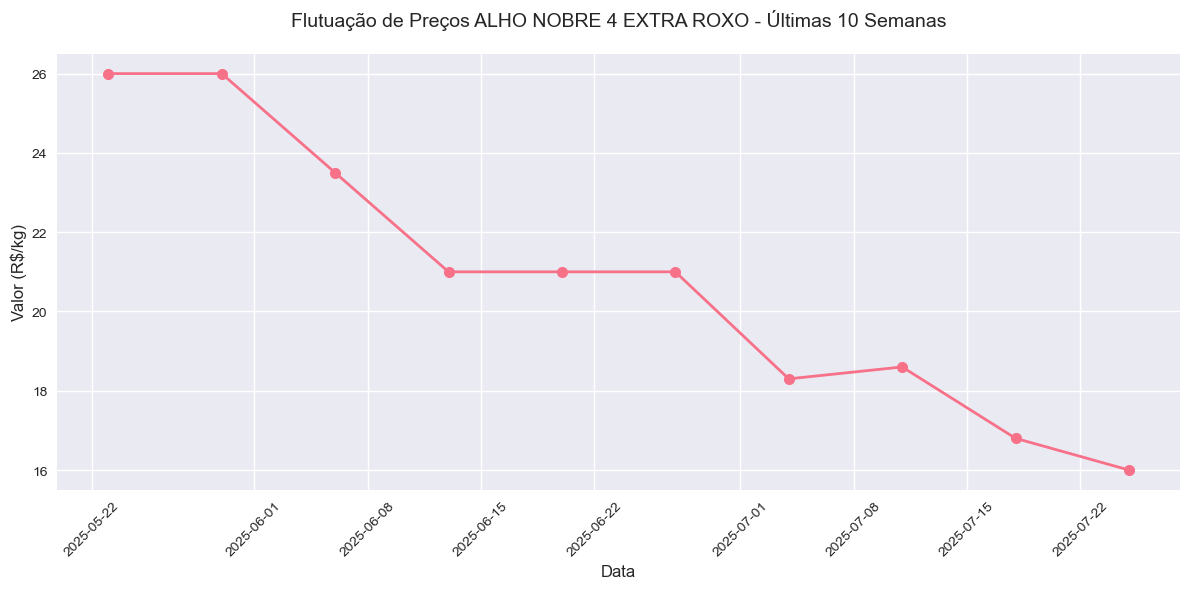

In [18]:
# ALHO NOBRE 4 EXTRA ROXO em 10 semanas
# Configurar o estilo do gráfico
plt.style.use('seaborn')
sns.set_palette("husl")

# Ordenar o dataframe por data_final e pegar as últimas 12 datas
df_ultimas_12 = df_padap_2025_alho_N4ER.sort_values('data_final').tail(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_ultimas_12['data_final'], df_ultimas_12['valor_produto_kg'], 
         marker='o', linewidth=2, markersize=8)

# Customizar o gráfico
plt.title('Flutuação de Preços ALHO NOBRE 4 EXTRA ROXO - Últimas 10 Semanas', fontsize=14, pad=20)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor (R$/kg)', fontsize=12)

# Rotacionar datas no eixo x para melhor visualização
plt.xticks(rotation=45)

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

#### Gráfico flutuação de preços ALHO NOBRE 5 EXTRA ROXO em 10 semanas

C:\Users\diego\AppData\Local\Temp\ipykernel_29736\457164053.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


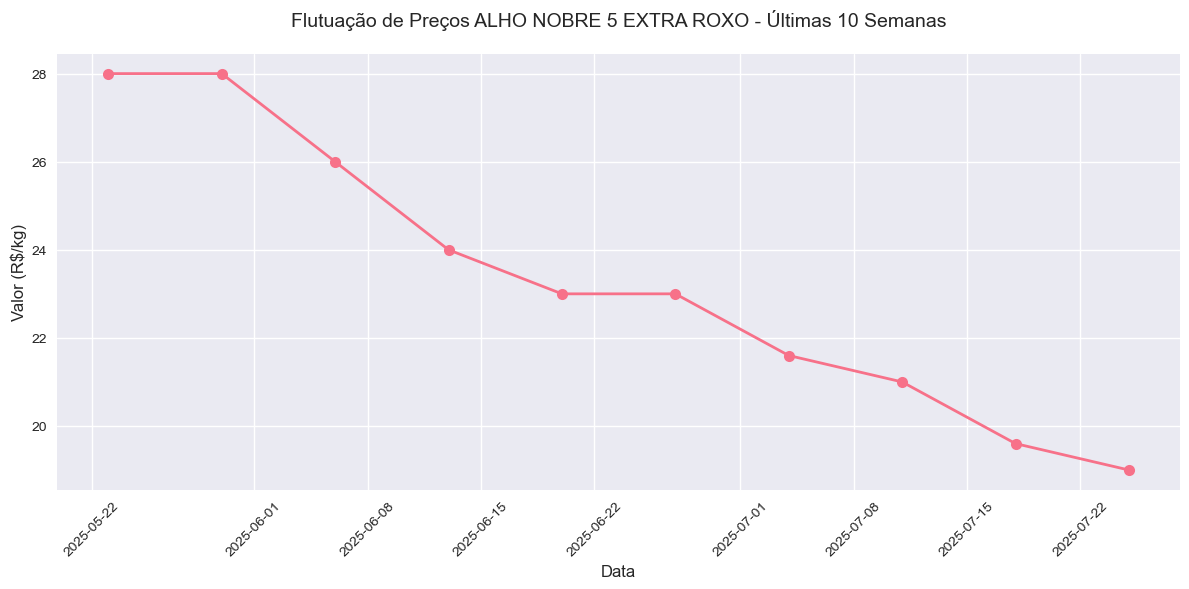

In [19]:
# ALHO NOBRE 5 EXTRA ROXO em 10 semanas
# Configurar o estilo do gráfico
plt.style.use('seaborn')
sns.set_palette("husl")

# Ordenar o dataframe por data_final e pegar as últimas 12 datas
df_ultimas_12 = df_padap_2025_alho_N5ER.sort_values('data_final').tail(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_ultimas_12['data_final'], df_ultimas_12['valor_produto_kg'], 
         marker='o', linewidth=2, markersize=8)

# Customizar o gráfico
plt.title('Flutuação de Preços ALHO NOBRE 5 EXTRA ROXO - Últimas 10 Semanas', fontsize=14, pad=20)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor (R$/kg)', fontsize=12)

# Rotacionar datas no eixo x para melhor visualização
plt.xticks(rotation=45)

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

#### Gráfico flutuação de preços ALHO NOBRE 6 EXTRA ROXO em 10 semanas

C:\Users\diego\AppData\Local\Temp\ipykernel_29736\2692238283.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


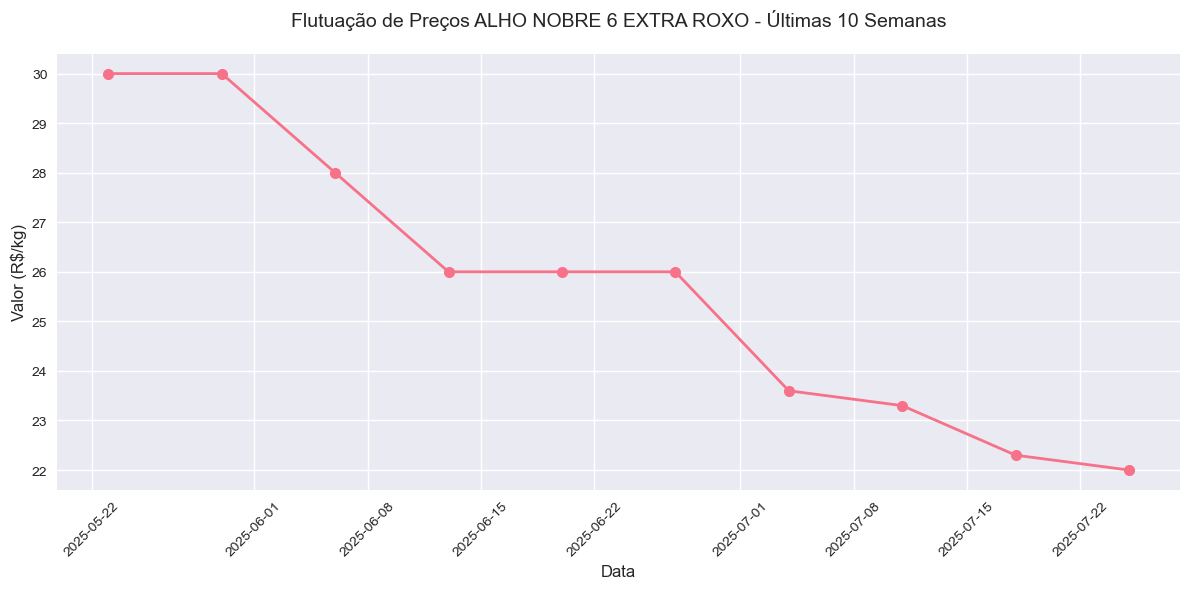

In [20]:
# NOBRE 6 EXTRA ROXO em 10 semanas
# Configurar o estilo do gráfico
plt.style.use('seaborn')
sns.set_palette("husl")

# Ordenar o dataframe por data_final e pegar as últimas 12 datas
df_ultimas_12 = df_padap_2025_alho_N6ER.sort_values('data_final').tail(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_ultimas_12['data_final'], df_ultimas_12['valor_produto_kg'], 
         marker='o', linewidth=2, markersize=8)

# Customizar o gráfico
plt.title('Flutuação de Preços ALHO NOBRE 6 EXTRA ROXO - Últimas 10 Semanas', fontsize=14, pad=20)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor (R$/kg)', fontsize=12)

# Rotacionar datas no eixo x para melhor visualização
plt.xticks(rotation=45)

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()


#### Gráfico flutuação de preços ALHO NOBRE 7 COMERCIAL ROXO em 10 semanas

C:\Users\diego\AppData\Local\Temp\ipykernel_29736\3790089793.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


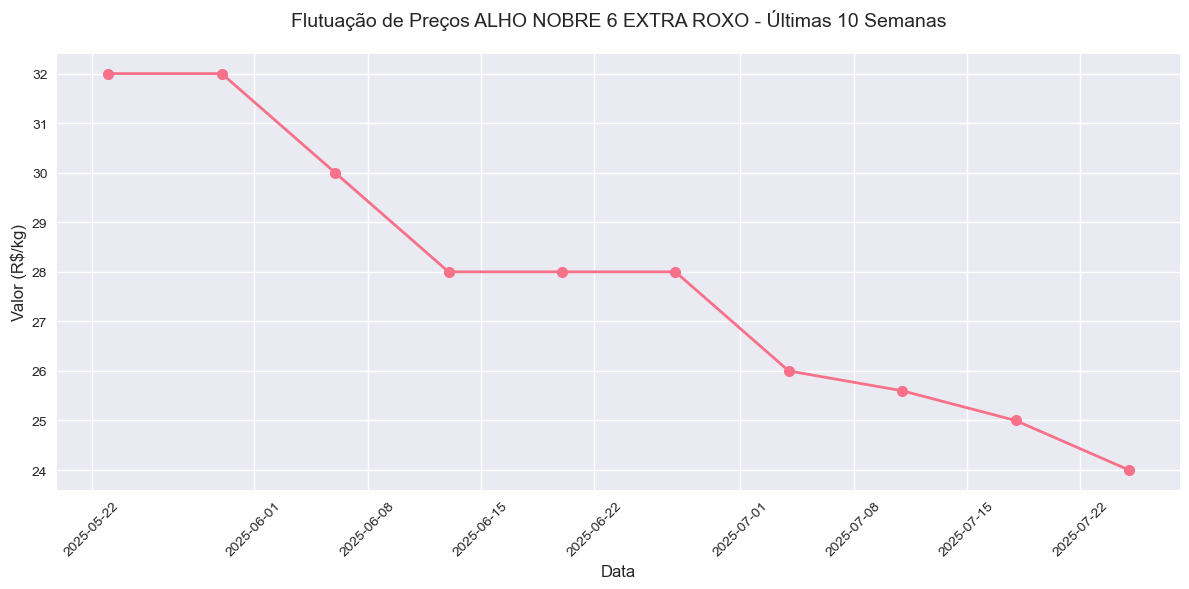

In [21]:
# NOBRE 7 COMERCIAL ROXO em 10 semanas
# Configurar o estilo do gráfico
plt.style.use('seaborn')
sns.set_palette("husl")

# Ordenar o dataframe por data_final e pegar as últimas 12 datas
df_ultimas_12 = df_padap_2025_alho_N7CRO.sort_values('data_final').tail(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_ultimas_12['data_final'], df_ultimas_12['valor_produto_kg'], 
         marker='o', linewidth=2, markersize=8)

# Customizar o gráfico
plt.title('Flutuação de Preços ALHO NOBRE 6 EXTRA ROXO - Últimas 10 Semanas', fontsize=14, pad=20)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor (R$/kg)', fontsize=12)

# Rotacionar datas no eixo x para melhor visualização
plt.xticks(rotation=45)

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

### Análise do CEBOLA 2025

In [22]:
# Cria o dataframe da cebola

df_padap_2025_cebola = df_padap_2025[df_padap_2025['produto'].str.upper().str.strip() == 'CEBOLA']
